# Customer Churn Prediction - Model Training and Stacking Ensemble

This notebook trains optimized models and combines them using stacking ensemble.

## Workflow
1. Train each model with optimized hyperparameters
2. Evaluate with classification metrics and confusion matrices
3. Build stacking ensemble with out-of-fold predictions
4. Compare all approaches

In [45]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

## Setup and Data Loading

Load scaled data (XGBoost, LightGBM) and raw data (CatBoost), plus optimized parameters.

In [46]:
# Load data and best params
X_train = joblib.load('../data/processed/X_train_scaled.pkl')
X_train_raw = joblib.load('../data/processed/x_train.pkl')
X_test = joblib.load('../data/processed/X_test_scaled.pkl')
X_test_raw = joblib.load('../data/processed/x_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')
feature_names= joblib.load('../data/processed/feature_names.pkl')
best_params = joblib.load('../models/optuna_best_params.pkl')

print("Loaded optimized parameters")

Loaded optimized parameters


## XGBoost Model

Train and evaluate XGBoost with optimized parameters.

In [47]:
# Train XGBoost
print("Training XGBoost...")
xgb_params = best_params['xgb_best_params']
xgb_params['random_state'] = 42
xgb_params['eval_metric'] = 'logloss'
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost - Acc: {xgb_acc:.4f}, F1: {xgb_f1:.4f}, AUC: {xgb_auc:.4f}")

Training XGBoost...
XGBoost - Acc: 0.7602, F1: 0.6092, AUC: 0.8048


Metrics reported:
- Accuracy: overall correctness
- F1-score: harmonic mean of precision and recall
- ROC-AUC: discrimination ability
- Feature importance: which features drive predictions


Top 5 Feature Importances:
          feature  importance
4        Contract    0.799925
2          Tenure    0.092429
3  MonthlyCharges    0.077907
6    TotalCharges    0.021887
0             Age    0.002798


C:\Users\khaou\AppData\Local\Temp\ipykernel_7328\2887359040.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_importance.head(10), x='importance', y='feature', palette='Blues_r')


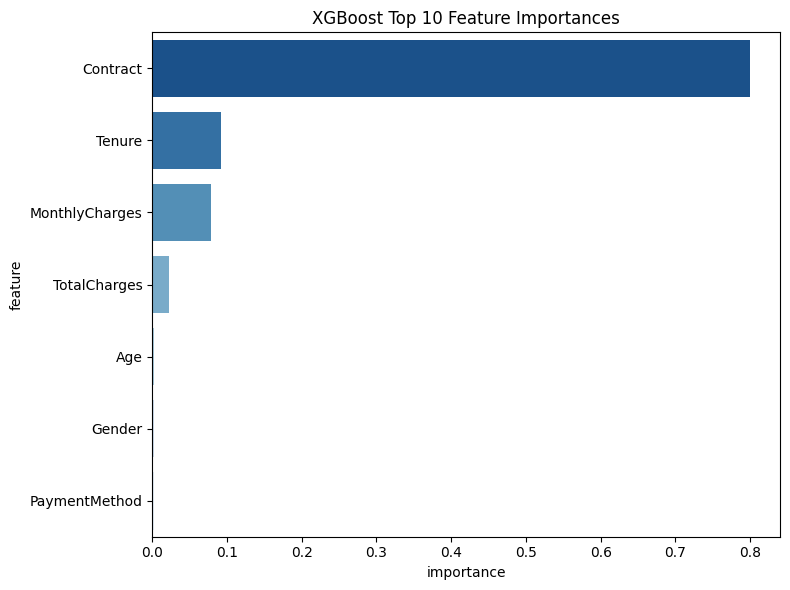

In [48]:
# Feature Importance
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Feature Importances:")
print(xgb_importance.head())

plt.figure(figsize=(8, 6))
sns.barplot(data=xgb_importance.head(10), x='importance', y='feature', palette='Blues_r')
plt.title('XGBoost Top 10 Feature Importances')
plt.tight_layout()
plt.show()

## LightGBM Model

Train and evaluate LightGBM with optimized parameters.

In [49]:
# Train LightGBM
print("Training LightGBM...")
lgb_params = best_params['lgb_best_params']
lgb_params['random_state'] = 42
lgb_params['verbose'] = -1
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

lgb_acc = accuracy_score(y_test, lgb_pred)
lgb_f1 = f1_score(y_test, lgb_pred)
lgb_auc = roc_auc_score(y_test, lgb_proba)

print(f"LightGBM - Acc: {lgb_acc:.4f}, F1: {lgb_f1:.4f}, AUC: {lgb_auc:.4f}")


Training LightGBM...
LightGBM - Acc: 0.7602, F1: 0.6099, AUC: 0.8045


### LightGBM Results

Same evaluation metrics as XGBoost for direct comparison.


Top 5 Feature Importances:
          feature  importance
3  MonthlyCharges        3422
6    TotalCharges        2663
2          Tenure        2417
0             Age        2139
5   PaymentMethod         590


C:\Users\khaou\AppData\Local\Temp\ipykernel_7328\2583147439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lgb_importance.head(10), x='importance', y='feature', palette='Blues_r')


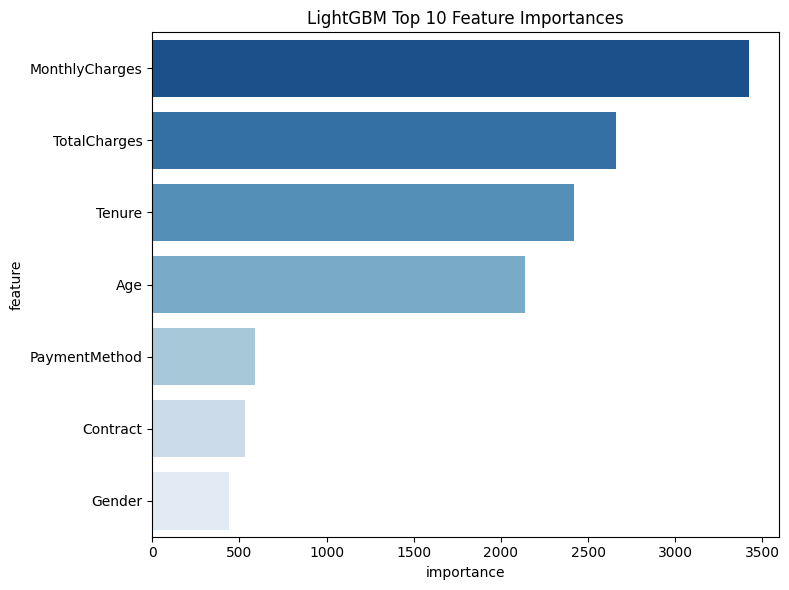

In [50]:
# Feature Importance
lgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Feature Importances:")
print(lgb_importance.head())

plt.figure(figsize=(8, 6))
sns.barplot(data=lgb_importance.head(10), x='importance', y='feature', palette='Blues_r')
plt.title('LightGBM Top 10 Feature Importances')
plt.tight_layout()
plt.show()

## CatBoost Model

Train and evaluate CatBoost with optimized parameters on raw (unscaled) data.

In [51]:
# Train CatBoost
print("Training CatBoost...")
cat_params = best_params['cat_best_params']
cat_params['random_seed'] = 42
cat_params['verbose'] = False
cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(X_train_raw, y_train)

cat_pred = cat_model.predict(X_test_raw)
cat_proba = cat_model.predict_proba(X_test_raw)[:, 1]

cat_acc = accuracy_score(y_test, cat_pred)
cat_f1 = f1_score(y_test, cat_pred)
cat_auc = roc_auc_score(y_test, cat_proba)

print(f"CatBoost - Acc: {cat_acc:.4f}, F1: {cat_f1:.4f}, AUC: {cat_auc:.4f}")


Training CatBoost...
CatBoost - Acc: 0.7602, F1: 0.6093, AUC: 0.8046


### CatBoost Results

Same evaluation metrics.


Top 5 Feature Importances:
          feature  importance
4        Contract   45.774155
3  MonthlyCharges   26.965837
2          Tenure   23.315614
6    TotalCharges    1.572991
0             Age    0.906841


C:\Users\khaou\AppData\Local\Temp\ipykernel_7328\2045896369.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_importance.head(10), x='importance', y='feature', palette='Blues_r')


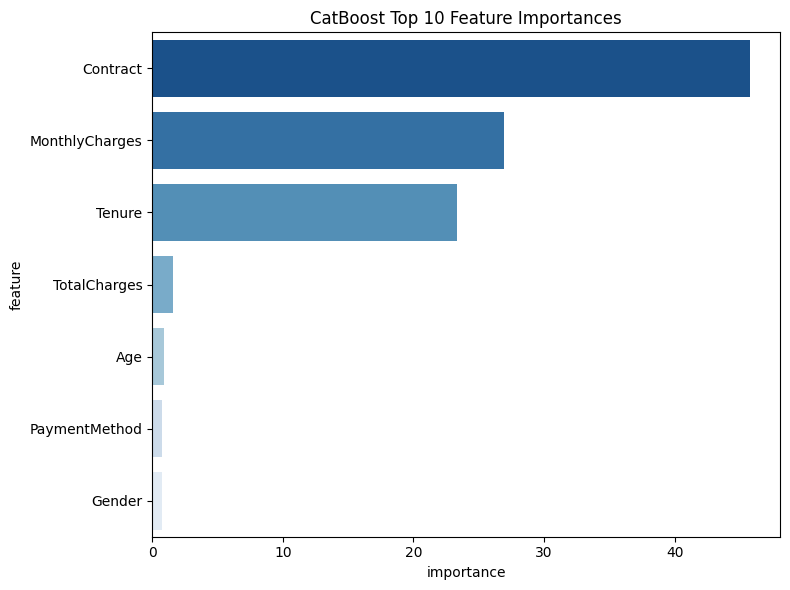

In [52]:
# Feature Importance
cat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': cat_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Feature Importances:")
print(cat_importance.head())

plt.figure(figsize=(8, 6))
sns.barplot(data=cat_importance.head(10), x='importance', y='feature', palette='Blues_r')
plt.title('CatBoost Top 10 Feature Importances')
plt.tight_layout()
plt.show()

## Stacking Ensemble

Combine all three models using a meta-learner (Logistic Regression).

### Why Stacking?
- Leverages strengths of different algorithms
- Reduces variance through diversification
- Meta-learner learns optimal weighting

### Implementation Details
- 5-fold cross-validation for out-of-fold predictions
- Prevents data leakage (critical for valid ensemble)
- Meta-features: predicted probabilities from base models

In [53]:
# Stacking with 3 base models
print("\nBuilding stacking ensemble...")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

xgb_oof = np.zeros(len(X_train))
lgb_oof = np.zeros(len(X_train))
cat_oof = np.zeros(len(X_train))

xgb_test_preds = np.zeros(len(X_test))
lgb_test_preds = np.zeros(len(X_test))
cat_test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {fold + 1}/{n_splits}")
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    
    # XGBoost fold
    xgb_fold = xgb.XGBClassifier(**xgb_params)
    xgb_fold.fit(X_tr, y_tr)
    xgb_oof[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]
    xgb_test_preds += xgb_fold.predict_proba(X_test)[:, 1] / n_splits
    
    # LightGBM fold
    lgb_fold = lgb.LGBMClassifier(**lgb_params)
    lgb_fold.fit(X_tr, y_tr)
    lgb_oof[val_idx] = lgb_fold.predict_proba(X_val)[:, 1]
    lgb_test_preds += lgb_fold.predict_proba(X_test)[:, 1] / n_splits
    
    # CatBoost fold
    cat_fold = CatBoostClassifier(**cat_params)
    cat_fold.fit(X_tr, y_tr)
    cat_oof[val_idx] = cat_fold.predict_proba(X_val)[:, 1]
    cat_test_preds += cat_fold.predict_proba(X_test)[:, 1] / n_splits


Building stacking ensemble...
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


### Stacking Results

Evaluate ensemble performance and interpret meta-learner weights.


Stacking - Acc: 0.7602, F1: 0.6098, AUC: 0.8048

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83     19961
           1       0.67      0.56      0.61     10039

    accuracy                           0.76     30000
   macro avg       0.73      0.71      0.72     30000
weighted avg       0.75      0.76      0.75     30000



Text(0.5, 1.0, 'Confusion Matrix')

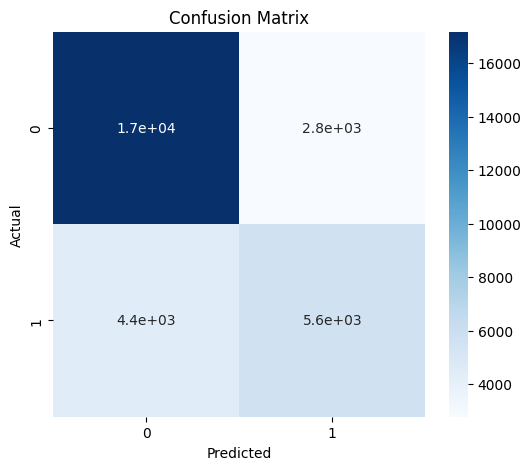

In [54]:
# Meta-learner with 4 models
meta_features_train = np.column_stack([xgb_oof, lgb_oof, cat_oof])
meta_features_test = np.column_stack([xgb_test_preds, lgb_test_preds, cat_test_preds])

meta_learner = LogisticRegression(random_state=42)
meta_learner.fit(meta_features_train, y_train)

stack_proba = meta_learner.predict_proba(meta_features_test)[:, 1]
stack_pred = (stack_proba > 0.5).astype(int)

stack_acc = accuracy_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_proba)


print(f"\nStacking - Acc: {stack_acc:.4f}, F1: {stack_f1:.4f}, AUC: {stack_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, stack_pred))

con_mat= confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(6,5))
sns.heatmap(con_mat, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

## Final Model Comparison

Compare all approaches across key metrics.

In [55]:
# Results comparison
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'Stacking'],
    'Accuracy': [xgb_acc, lgb_acc, cat_acc, stack_acc],
    'F1': [xgb_f1, lgb_f1, cat_f1, stack_f1],
    'ROC_AUC': [xgb_auc, lgb_auc, cat_auc, stack_auc]
})

print("\nFinal Results:")
print(results.to_string(index=False))


Final Results:
   Model  Accuracy       F1  ROC_AUC
 XGBoost  0.760167 0.609201 0.804806
LightGBM  0.760200 0.609912 0.804499
CatBoost  0.760167 0.609328 0.804638
Stacking  0.760167 0.609752 0.804825


### Meta-Learner Interpretation

Coefficients indicate how much the ensemble trusts each base model:
- Higher positive weight = more influence on final prediction
- Negative weight would indicate inverse relationship (rare)

In [56]:
# Meta-learner weights
print(f"\nMeta-learner coefficients:")
print(f"XGBoost: {meta_learner.coef_[0][0]:.4f}")
print(f"LightGBM: {meta_learner.coef_[0][1]:.4f}")
print(f"CatBoost: {meta_learner.coef_[0][2]:.4f}")


Meta-learner coefficients:
XGBoost: -3.2942
LightGBM: 4.9213
CatBoost: 4.2691



FEATURE IMPORTANCE COMPARISON

Normalized Feature Importances (0-100 scale):
          feature  importance_xgb  importance_lgb  importance_cat  average
0        Contract          100.00           15.49          100.00    71.83
2  MonthlyCharges            9.74          100.00           58.91    56.22
1          Tenure           11.55           70.63           50.94    44.37
3    TotalCharges            2.74           77.82            3.44    28.00
4             Age            0.35           62.51            1.98    21.61
6   PaymentMethod            0.31           17.24            1.65     6.40
5          Gender            0.32           12.83            1.55     4.90


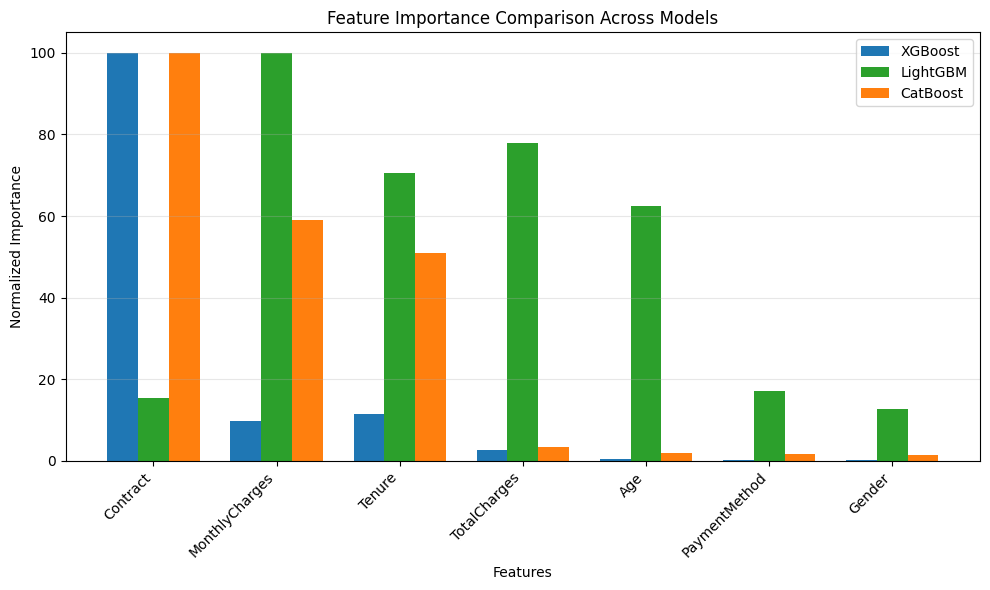

In [ ]:
# Combined Feature Importance Comparison
print("\n" + "="*50)
print("FEATURE IMPORTANCE COMPARISON")
print("="*50)

# Merge all importances
all_importance = xgb_importance.merge(
    lgb_importance, on='feature', suffixes=('_xgb', '_lgb')
).merge(
    cat_importance, on='feature'
).rename(columns={'importance': 'importance_cat'})

# Normalize to 0-100 scale for comparison
for col in ['importance_xgb', 'importance_lgb', 'importance_cat']:
    all_importance[col] = 100 * all_importance[col] / all_importance[col].max()

all_importance['average'] = all_importance[['importance_xgb', 'importance_lgb', 'importance_cat']].mean(axis=1)
all_importance = all_importance.sort_values('average', ascending=False)

print("\nNormalized Feature Importances (0-100 scale):")
print(all_importance.round(2))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(all_importance))
width = 0.25

ax.bar(x - width, all_importance['importance_xgb'], width, label='XGBoost', color='#1f77b4')
ax.bar(x, all_importance['importance_lgb'], width, label='LightGBM', color='#2ca02c')
ax.bar(x + width, all_importance['importance_cat'], width, label='CatBoost', color='#ff7f0e')

ax.set_xlabel('Features')
ax.set_ylabel('Normalized Importance')
ax.set_title('Feature Importance Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(all_importance['feature'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Key Findings

Typical insights from churn prediction:
- **Contract type**: Month-to-month customers churn more
- **Tenure**: New customers have higher churn risk
- **MonthlyCharges**: Price sensitivity drives churn
- **PaymentMethod**: Electronic check users less sticky

In [ ]:
# Save
joblib.dump(xgb_model, '../models/xgboost_optimized.pkl')
joblib.dump(lgb_model, '../models/lightgbm_optimized.pkl')
joblib.dump(cat_model, '../models/catboost_optimized.pkl')
joblib.dump(meta_learner, '../models/meta_learner.pkl')
joblib.dump(results, '../models/final_results.pkl')

['../models/final_results.pkl']